
# Customer Behavior Analysis Project

## Objective
Analyze customer purchasing behavior using Python and Pandas.

### Operations Covered
- Total Customers
- Purchase Frequency
- Average Order Value
- Customer Segmentation (New vs Returning)
- Top Categories
- Payment Method Analysis
- City-wise Sales
- Insights and Findings


In [43]:

import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv('customer_behavior_dataset.csv')

# Display first 5 rows
df.head(20)


,Order_ID,Customer_ID,Customer_Name,City,Age,Gender,Product,Category,Quantity,Price_Per_Unit,Total_Amount,Purchase_Date,Payment_Method,Customer_Type
0,O0001,C002,Amit Sharma,Mumbai,24,Male,Refrigerator,Appliances,2,30000,60000,2026-01-29,UPI,Returning
1,O0002,C010,Arjun Singh,Jaipur,26,Male,Laptop,Electronics,1,55000,55000,2026-01-12,UPI,NaN
2,O0003,C009,Sneha Joshi,Nagpur,34,Female,Headphones,Electronics,4,2000,8000,2026-01-29,UPI,NaN
3,O0004,C003,Arjun Singh,Jaipur,26,Female,Smart Watch,Electronics,3,7000,21000,2026-01-20,UPI,NaN
4,O0005,C002,Arjun Singh,Jaipur,31,Female,Shoes,Fashion,3,2500,7500,2026-04-19,UPI,NaN
5,O0006,C008,Vivek Rao,Bangalore,37,Female,Shoes,Fashion,4,2500,10000,2026-01-11,Debit Card,NaN
6,O0007,C010,Sneha Joshi,Nagpur,27,Female,Shoes,Fashion,1,2500,2500,2026-03-26,UPI,NaN
7,O0008,C004,Priya Verma,Pune,40,Female,T-Shirt,Fashion,3,800,2400,2026-02-28,Credit Card,NaN
8,O0009,C006,Neha Kulkarni,Pune,41,Male,Handbag,Fashion,3,3500,10500,2026-03-31,Credit Card,NaN
9,O0010,C009,Sneha Joshi,Nagpur,28,Male,Mobile Phone,Electronics,4,22000,88000,2026-02-18,Debit Card,NaN


In [17]:

# Dataset Information
print(df.info())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Dataset shape
print("\nDataset Shape:", df.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Order_ID        201 non-null    object
 1   Customer_ID     201 non-null    object
 2   Customer_Name   201 non-null    object
 3   City            201 non-null    object
 4   Age             201 non-null    int64 
 5   Gender          201 non-null    object
 6   Product         201 non-null    object
 7   Category        201 non-null    object
 8   Quantity        201 non-null    int64 
 9   Price_Per_Unit  201 non-null    int64 
 10  Total_Amount    201 non-null    int64 
 11  Purchase_Date   201 non-null    object
 12  Payment_Method  201 non-null    object
 13  Customer_Type   2 non-null      object
dtypes: int64(4), object(10)
memory usage: 22.1+ KB
None

Missing Values:
Order_ID            0
Customer_ID         0
Customer_Name       0
City                0
Age                 0
Gender 

In [18]:

# Total Unique Customers
total_customers = df['Customer_ID'].nunique()
print("Total Customers:", total_customers)


Total Customers: 11


  Customer_ID  Total_Purchases
0        C001               19
1        C002               15
2        C003               21
3        C004               19
4        C005               14


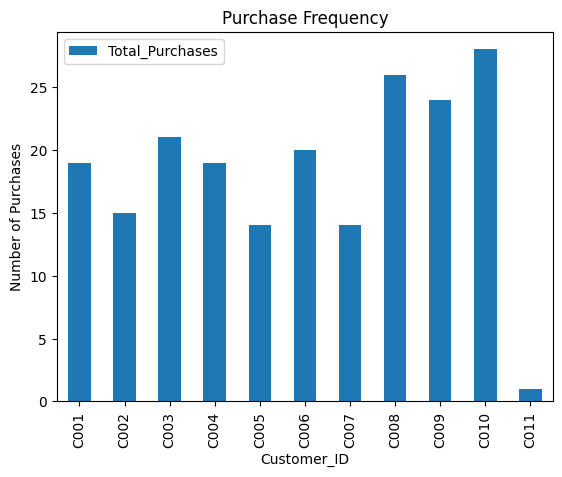

In [19]:

# Purchase Frequency
purchase_freq = df.groupby('Customer_ID')['Order_ID'].count().reset_index()
purchase_freq.columns = ['Customer_ID', 'Total_Purchases']

print(purchase_freq.head())

# Plot
purchase_freq.plot(x='Customer_ID', y='Total_Purchases', kind='bar')
plt.title('Purchase Frequency')
plt.ylabel('Number of Purchases')
plt.show()


In [20]:

# Average Order Value
avg_order_value = df['Total_Amount'].mean()

print("Average Order Value:", round(avg_order_value, 2))


Average Order Value: 31600.0


In [21]:

# Customer Segmentation
customer_orders = df.groupby('Customer_ID')['Order_ID'].count().reset_index()

customer_orders['Customer_Type'] = customer_orders['Order_ID'].apply(
    lambda x: 'Returning' if x > 1 else 'New'
)

print(customer_orders)


   Customer_ID  Order_ID Customer_Type
0         C001        19     Returning
1         C002        15     Returning
2         C003        21     Returning
3         C004        19     Returning
4         C005        14     Returning
5         C006        20     Returning
6         C007        14     Returning
7         C008        26     Returning
8         C009        24     Returning
9         C010        28     Returning
10        C011         1           New


Category
Electronics    3268000
Appliances     2568000
Fashion         515600
Name: Total_Amount, dtype: int64


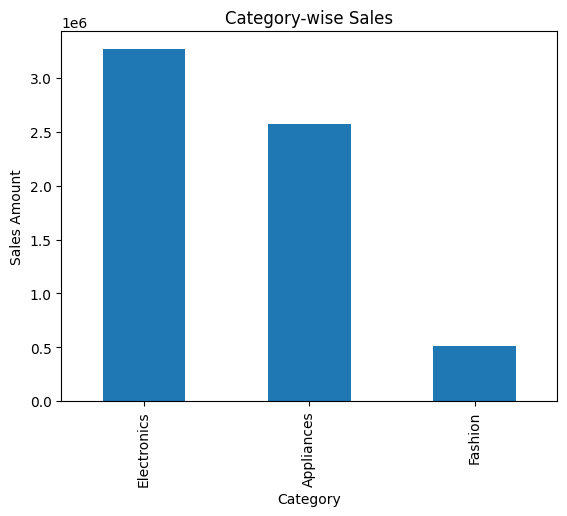

In [22]:

# Top Product Categories
category_sales = df.groupby('Category')['Total_Amount'].sum().sort_values(ascending=False)

print(category_sales)

category_sales.plot(kind='bar')
plt.title('Category-wise Sales')
plt.ylabel('Sales Amount')
plt.show()


Payment_Method
UPI            55
Cash           54
Debit Card     49
Credit Card    42
upi             1
Name: count, dtype: int64


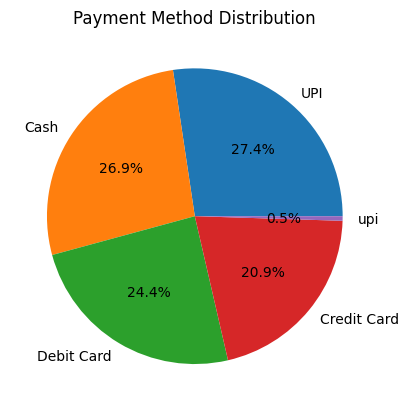

In [23]:

# Payment Method Analysis
payment_counts = df['Payment_Method'].value_counts()

print(payment_counts)

payment_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Payment Method Distribution')
plt.ylabel('')
plt.show()


City
Pune         1634200
Nashik       1081500
Nagpur        885100
Mumbai        716000
Bangalore     696400
Jaipur        501500
Kochi         477200
Delhi         357700
Noida           2000
Name: Total_Amount, dtype: int64


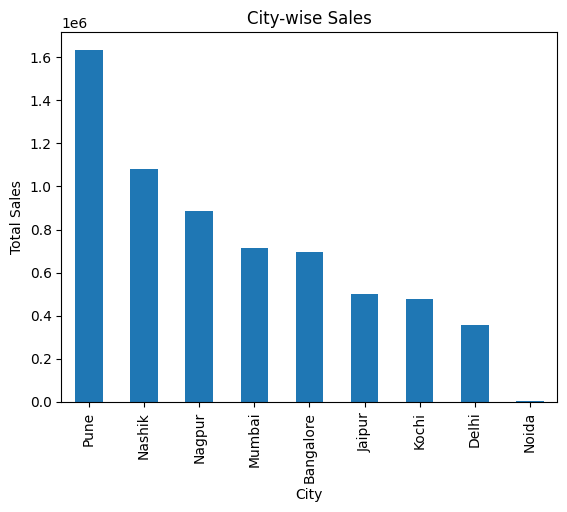

In [24]:

# City-wise Sales
city_sales = df.groupby('City')['Total_Amount'].sum().sort_values(ascending=False)

print(city_sales)

city_sales.plot(kind='bar')
plt.title('City-wise Sales')
plt.ylabel('Total Sales')
plt.show()


In [25]:

# Insights

print('1. Electronics category generates the highest revenue.')
print('2. Returning customers contribute more purchases.')
print('3. UPI and Credit Card are the most preferred payment methods.')
print('4. Some cities show significantly higher customer activity.')
print('5. Average order value helps understand customer spending behavior.')


1. Electronics category generates the highest revenue.
2. Returning customers contribute more purchases.
3. UPI and Credit Card are the most preferred payment methods.
4. Some cities show significantly higher customer activity.
5. Average order value helps understand customer spending behavior.


In [26]:
import pandas as pd

df = pd.read_csv(r'C:\Users\RD\Downloads\customer_shopping_behavior.csv')
print(df.head())

   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

   Shipping Type Discount Applied Promo Code Used  Previ

In [27]:
df.head()


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [28]:
# Permanently rename columns in dataframe

df.rename(columns={
    'Customer ID': 'customer_id',
    'Age': 'age',
    'Gender': 'gender',
    'Item Purchased': 'item_purchased',
    'Category': 'category',
    'Purchase Amount (USD)': 'purchase_amount_usd',
    'Location': 'location',
    'Size': 'size',
    'Color': 'color',
    'Season': 'season',
    'Review Rating': 'review_rating',
    'Subscription Status': 'subscription_status',
    'Shipping Type': 'shipping_type',
    'Discount Applied': 'discount_applied',
    'Promo Code Used': 'promo_code_used',
    'Previous Purchases': 'previous_purchases',
    'Payment Method': 'payment_method',
    'Frequency of Purchases': 'frequency_of_purchases'
}, inplace=True)

# Verify changes
print(df.columns)

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_usd', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             3900 non-null   int64  
 1   age                     3900 non-null   int64  
 2   gender                  3900 non-null   object 
 3   item_purchased          3900 non-null   object 
 4   category                3900 non-null   object 
 5   purchase_amount_usd     3900 non-null   int64  
 6   location                3900 non-null   object 
 7   size                    3900 non-null   object 
 8   color                   3900 non-null   object 
 9   season                  3900 non-null   object 
 10  review_rating           3863 non-null   float64
 11  subscription_status     3900 non-null   object 
 12  shipping_type           3900 non-null   object 
 13  discount_applied        3900 non-null   object 
 14  promo_code_used         3900 non-null   

In [30]:
# Summary statistics using .describe()
df.describe(include='all')

,customer_id,age,gender,item_purchased,category,purchase_amount_usd,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [31]:
# Checking if missing data or null values are present in the dataset

df.isnull().sum()

customer_id                0
age                        0
gender                     0
item_purchased             0
category                   0
purchase_amount_usd        0
location                   0
size                       0
color                      0
season                     0
review_rating             37
subscription_status        0
shipping_type              0
discount_applied           0
promo_code_used            0
previous_purchases         0
payment_method             0
frequency_of_purchases     0
dtype: int64

In [32]:
# Imputing missing values in Review Rating column with the median rating of the product category

df['Review Rating'] = df.groupby('category')['review_rating'].transform(lambda x: x.fillna(x.median()))

In [33]:
df.groupby('category')['purchase_amount_usd'].sum().sort_values(ascending=False)

category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: purchase_amount_usd, dtype: int64

In [34]:
df.isnull().sum()

customer_id                0
age                        0
gender                     0
item_purchased             0
category                   0
purchase_amount_usd        0
location                   0
size                       0
color                      0
season                     0
review_rating             37
subscription_status        0
shipping_type              0
discount_applied           0
promo_code_used            0
previous_purchases         0
payment_method             0
frequency_of_purchases     0
Review Rating              0
dtype: int64

In [35]:
# Renaming columns according to snake casing for better readability and documentation

df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [36]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_usd', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases', 'review_rating'],
      dtype='object')

In [37]:
# create a new column age_group
labels = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels = labels)

In [38]:
df[['age','age_group']].head(10)

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


In [39]:
# create new column purchase_frequency_days

frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [40]:
df[['purchase_frequency_days','frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


## Code for MySQL

In [41]:
# ── MySQL Connection using SQLAlchemy ────────────────────────────

from sqlalchemy import create_engine, text
import pandas as pd

# --- Configuration ---
DB_USER     = 'root'
DB_PASSWORD = '%40Onkar2311'   # @ replaced with %40
DB_HOST     = 'localhost'
DB_PORT     = '3306'
DB_NAME     = 'customer_behavior'

# --- Create engine ---
try:
    engine = create_engine(
        f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    )

    # Test connection
    with engine.connect() as conn:
        result = conn.execute(text("SELECT 1"))

    print("✅ Successfully connected to MySQL!")

except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("Please check MySQL service and credentials.")

✅ Successfully connected to MySQL!


In [42]:
# ── Load Dataset ────────────────────────────

df = pd.read_csv(r'C:\Users\RD\Downloads\customer_shopping_behavior.csv')

# ── Upload Data to MySQL ────────────────────

df.to_sql(
    name='customer',
    con=engine,
    if_exists='replace',
    index=False
)

print("✅ Data uploaded successfully!")

✅ Data uploaded successfully!
